<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/02_Clasificación_lineal/mincuadbin.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [ ]:
#########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)              #
# E-mail: wgomez@cinvestav.mx                           #
# Curso:   Análisis de datos                            #
# Tópico:  Mínimos cuadrados caso binario               #
#########################################################

Carga bibliotecas necesarias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Genera el conjunto de datos

In [ ]:
dataset = 1 #@param {type:"integer"}
if dataset == 1:
    # Linealmente separable
    x1 = np.array([[1.9, 7.2], [2.9, 6.2], [2.9, 6.8], [3.2, 6], [4, 6.7], [4.2, 5.8], [5.8, 2.6]]).T
    x2 = np.array([[2, 5.4], [4.1, 1.8], [4.3, 1.2], [4.5, 2.2], [5, 1], [5.3, 1.7], [5.7, 1.4]]).T
elif dataset == 2:
    # Outlier
    x1 = np.array([[-.25, .9], [-0.05, 0.5], [0, -0.4], [0.1, -0.5], [0.2, -0.8], [0.25, 0.8], [-.9, .9]]).T
    x2 = np.array([[0.5, 0.9], [0.6, 0.2], [0.6, -0.4], [0.5, -0.9], [0.8, 0.4], [0.85, -0.2], [0.8, -0.7]]).T
elif dataset == 3:
    # No Linealmente separable
    x1 = np.array([[2, 1], [1.5, 2], [2.5, 2.5], [1, 3], [2, 4], [2, 5.5], [3, 4.5], [3.5, 3]]).T
    x2 = np.array([[3.5, 5], [2.5, 6], [3.5, 4], [5.5, 6], [4.5, 4.5], [4.5, 3], [2.5, 3.5]]).T
# Conjunto de datos completo
x = np.concatenate((x1, x2), axis=1)
# Etiquetas de clase {-1,+1}
y = np.concatenate((-np.ones((1, x1.shape[1])), np.ones((1, x2.shape[1]))), axis=1)
# Aumenta vectores para cálculo del bias
x = np.concatenate((np.ones((1, y.size)), x), axis=0)
d, n = x.shape # dimensiones x muestras

Entrena el vector de pesos con métodos de mínimos cuadrados

In [ ]:
metodo = 3 #@param {type:"integer"}
if metodo == 1: # Solución directa
  l = 1e-6;
  W = np.linalg.inv(x @ x.T + l * np.eye(d)) @ x @ y.T
elif metodo == 2: # Descenso de gradiente
  eta = 0.005 # Tasa de aprendizaje
  tmax = 10000 # Número de iteraciones
  t = k = 0
  W = np.zeros(d) # Vector de pesos
  while t < tmax:
    t += 1
    W = W + eta * (y[0, k] - np.dot(W,x[:, k])) * x[:, k] # Actualización de pesos
    k = (k + 1) % n # Índice de la siguiente muestra
  W = W.reshape(d, 1)
elif metodo == 3: # Método de Ho-Kashyap
  id = (y == 1).flatten()
  x[:, id] = -1 * x[:, id] # Se cambia el signo de una clase
  y = np.ones((1, n)) # Inicializa parámetro del margen
  eta = 0.1 # Tasa de aprendizaje
  tmax = 10000 # Número de iteraciones
  x_ = np.linalg.pinv(x).T # Pseudoinversa de los datos
  W = x_ @ y.T # Inicializa vector de pesos
  t = 0 # Iteraciones
  while t < tmax:
    t += 1
    e = W.T @ x - y # Vector de error
    y = y + eta * (e + np.abs(e)) # Actualiza parámetro del margen
    W = x_ @ y.T # ACtualiza vector de pesos
else:
  raise ValueError("Método no reconocido")
print(f"Vector de pesos:\n {W}")

Vector de pesos:
 [[-13.24400386]
 [  1.77504547]
 [  1.51874621]]


Grafica la frontera de decisión

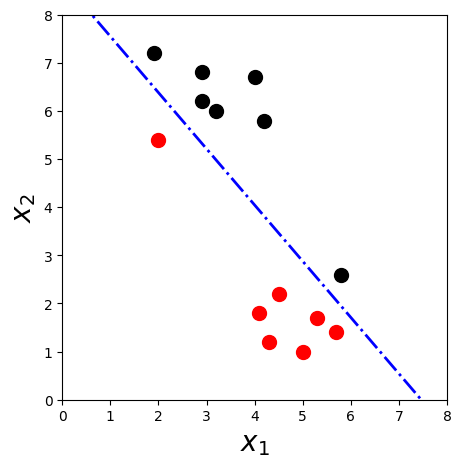

In [ ]:
if dataset == 1:
    Xgrid = np.linspace(0, 8, 100)
elif dataset == 2:
    Xgrid = np.linspace(-1, 1, 100)
elif dataset == 3:
    Xgrid = np.linspace(0, 7, 100)
Ygrid = (-W[0, 0] - W[1, 0] * Xgrid) / W[2, 0]

plt.figure(facecolor=[1, 1, 1], figsize=(5, 5))
plt.plot(x1[0, :], x1[1, :], 'ko', markerfacecolor='k', markersize=10)
plt.plot(x2[0, :], x2[1, :], 'o', markerfacecolor='r', markeredgecolor='r', markersize=10)
plt.plot(Xgrid, Ygrid, '-.', color='b', linewidth=2)

ax = plt.gca()
if dataset == 1:
    plt.axis([0, 8, 0, 8])
elif dataset == 2:
    plt.axis([-1, 1, -1, 1])
elif dataset == 3:
    plt.axis([0, 7, 0, 7])
plt.box(True)
ax.set_aspect('equal', adjustable='box')

plt.xlabel(r'${x}_1$', fontsize=20)
plt.ylabel(r'${x}_2$', fontsize=20)
plt.show()